In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)  #Sets the default size of every figure 
plt.rcParams['axes.titlesize'] = 14       #Sets the default font size of every chart title

In [3]:
df = pd.read_csv('AirQualityUCI__.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')  # list of column names 
df.head()

Shape: (9357, 15)
Columns: ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


### PreProcessing 

In [4]:
# Show how many -200s exist per column
print('Missing value (-200) :')
print((df == -200).sum())

Missing value (-200) :
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [5]:
# Drop NMHC(GT) 8443/9357 (90%) rows are missing  
df.drop(columns=['NMHC(GT)'], inplace=True)
df.shape

(9357, 14)

In [6]:
# Replace ALL -200 with NaN 
df.replace(-200, np.nan, inplace=True)
print('NaN counts:')
print(df.isnull().sum())

NaN counts:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [7]:
df.head(10)

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.600,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.300,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.900,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.000,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.150,59.575001,0.788794
5,2004-03-10,23:00:00,1.2,1197.00,4.741012,750.25,89.0,1336.50,96.0,1393.00,949.25,11.175,59.175000,0.784772
6,2004-03-11,00:00:00,1.2,1185.00,3.624399,689.50,62.0,1461.75,77.0,1332.75,732.50,11.325,56.775000,0.760312
7,2004-03-11,01:00:00,1.0,1136.25,3.326677,672.00,62.0,1453.25,76.0,1332.75,729.50,10.675,60.000000,0.770238
8,2004-03-11,02:00:00,0.9,1094.00,2.339416,608.50,45.0,1579.00,60.0,1276.00,619.50,10.650,59.674999,0.764819
9,2004-03-11,03:00:00,0.6,1009.75,1.696658,560.75,NaN,1705.00,NaN,1234.75,501.25,10.250,60.200001,0.751657


In [8]:
#we will  Drop rows where TARGET is NaN because we can't train without a label
before = len(df)
df.dropna(subset=['C6H6(GT)'], inplace=True)
print(f'Rows removed (missing target): {before - len(df)}')
print(f'Remaining rows: {len(df)}')

Rows removed (missing target): 366
Remaining rows: 8991


# Handel missing data

In [9]:
# Impute the  remaining NaNs in features with  MEDIAN
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print('NaN counts  :')
print(df.isnull().sum())


NaN counts  :
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


After dropping rows with a missing target, some feature columns still contain NaN values from sensor dropouts and weather station gaps. We impute these with the column median — a robust choice that is unaffected by the extreme outliers present in pollution data.

In [10]:
# Parse DateTime and set as index ,important to feature engineering
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time']) # Converts that string into a real Python datetime object
df.sort_values('DateTime', inplace=True)                       # time order (oldest To  newest)
df.set_index('DateTime', inplace=True)
df.drop(columns=['Date', 'Time'], inplace=True)                # drop the coulm because they are duplicates now 

print(f'Date range: {df.index.min()} → {df.index.max()}')
print(f'Final shape: {df.shape}')
df.head()

Date range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00
Final shape: (8991, 12)


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
DateTime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
2004-03-10 19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2004-03-10 20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
2004-03-10 21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


# Exploratory Data Analysis (EDA)
Before modeling, we examine the target variable and sensor correlations to understand the data's behavior and identify potential issues such as skewness or multicollinearity.

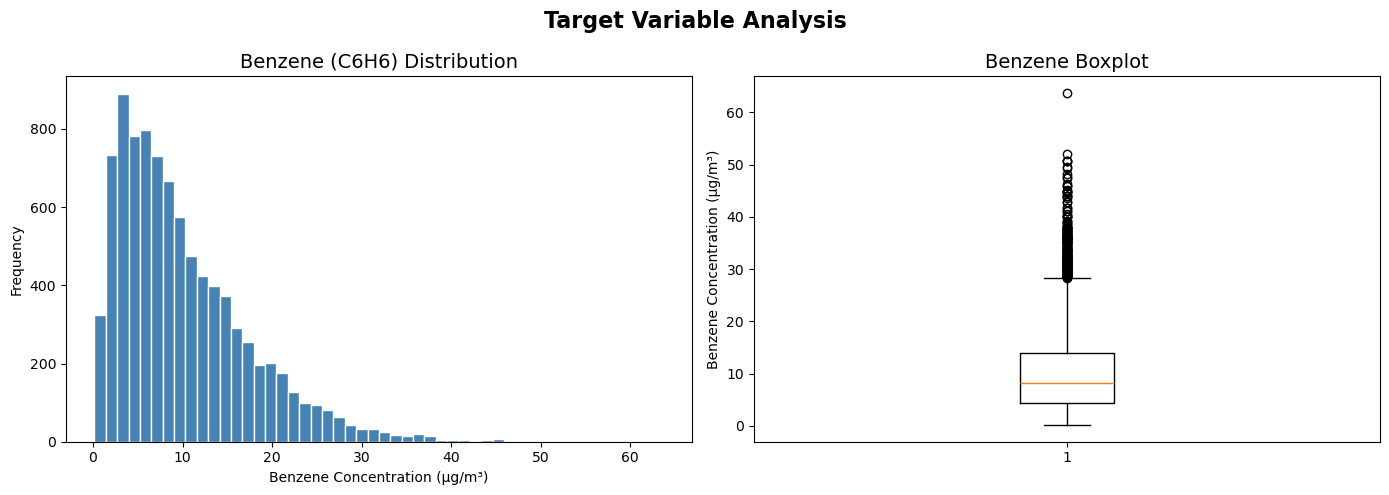

count    8991.000000
mean       10.082993
std         7.449640
min         0.149048
25%         4.436942
50%         8.239851
75%        13.988478
max        63.741476
Name: C6H6(GT), dtype: float64


In [11]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['C6H6(GT)'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Benzene (C6H6) Distribution')
axes[0].set_xlabel('Benzene Concentration (µg/m³)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['C6H6(GT)'])
axes[1].set_title('Benzene Boxplot')
axes[1].set_ylabel('Benzene Concentration (µg/m³)')

plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['C6H6(GT)'].describe())

# Benzene Concentration Over Time
Plotting C6H6 across the full year reveals clear daily and seasonal cycles — higher concentrations in winter mornings (temperature inversions trap pollutants) and lower in summer afternoons (thermal convection disperses them).

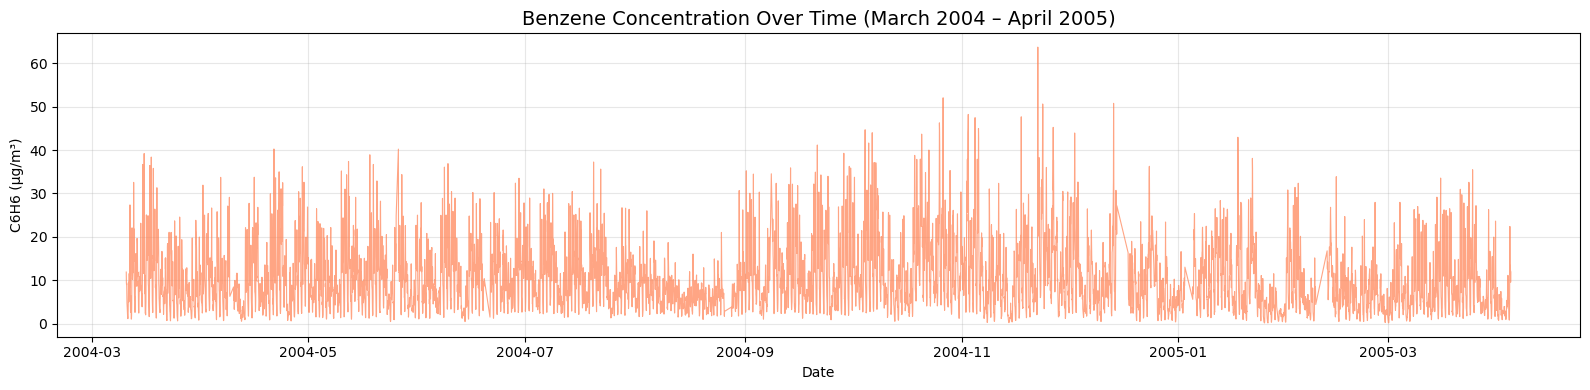

In [12]:
# Benzene over time
plt.figure(figsize=(16, 4))
plt.plot(df.index, df['C6H6(GT)'], color='coral', alpha=0.7, linewidth=0.8)
plt.title('Benzene Concentration Over Time (March 2004 – April 2005)')
plt.xlabel('Date')
plt.ylabel('C6H6 (µg/m³)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_benzene_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

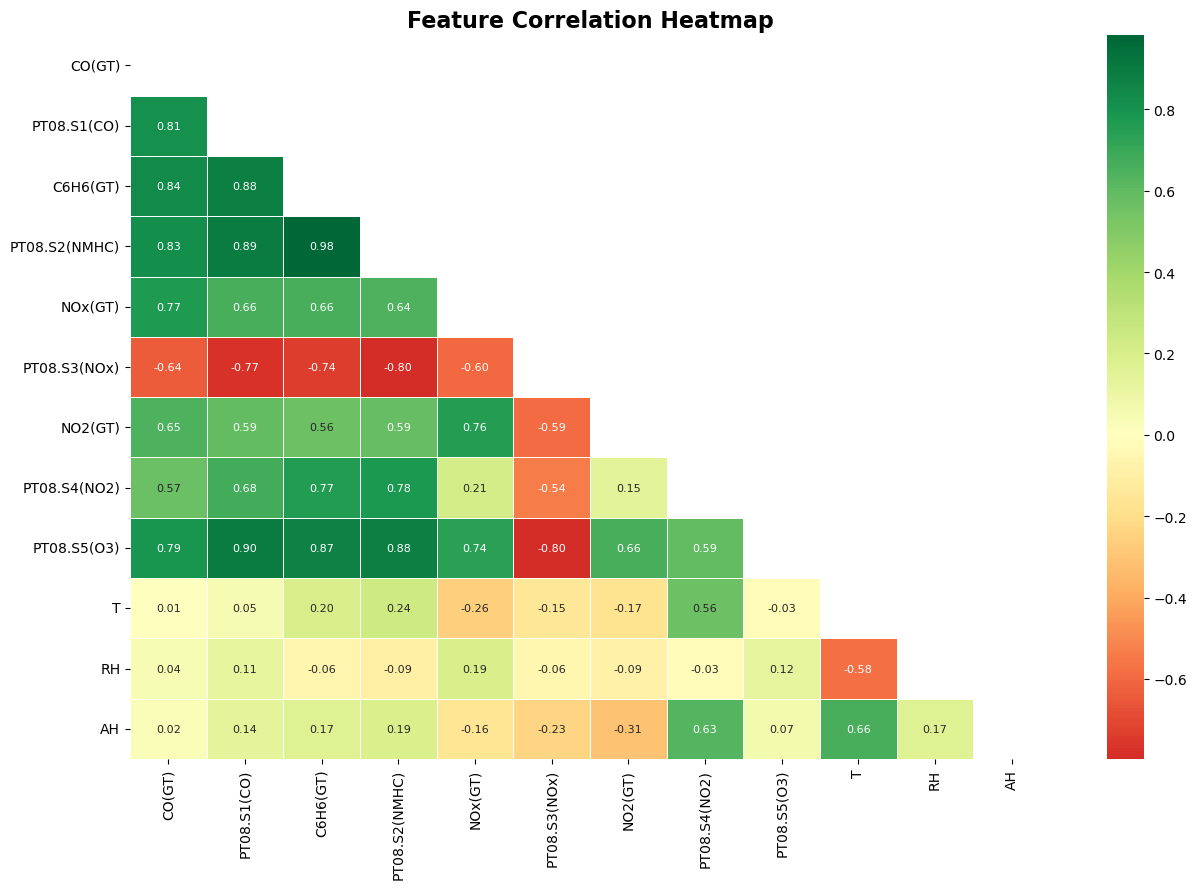

In [13]:
# Correlation heatmap
plt.figure(figsize=(13, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering
Raw sensor signals alone are insufficient — benzene concentration is heavily influenced by **human behavioral patterns** (rush hour traffic, weekday vs. weekend activity) and **seasonal weather cycles** that alter sensor chemistry.

We extract **5 temporal features** from the DateTime index:

| Feature | Description | Why It Matters |
|---|---|---|
| `Hour` | Hour of day (0–23) | Captures rush hour spikes (8am, 6pm) |
| `DayOfWeek` | 0=Monday … 6=Sunday | Weekday traffic vs. weekend patterns |
| `Month` | 1–12 | Seasonal pollution cycles |
| `Season` | 0=Spring … 3=Winter | Temperature inversions in winter concentrate benzene |
| `IsWeekend` | 0 or 1 | Binary flag for reduced weekday industrial activity |

# Feature Engineering

In [14]:
# Extract hour of day (0 = midnight, 23 = 11pm)
df['Hour'] = df.index.hour

# Extract day of week (0 = Monday, 6 = Sunday)
df['DayOfWeek'] = df.index.dayofweek

# Extract month (1 = January, 12 = December)
df['Month'] = df.index.month

# Create a weekend flag (1 = weekend, 0 = weekday)
df['IsWeekend'] = (df.index.dayofweek >= 5).astype(int)

# Map each month to its season
df['Season'] = df['Month'].map({
    12: 0, 1: 0, 2: 0,   # Winter  = 0
    3:  1, 4: 1, 5: 1,   # Spring  = 1
    6:  2, 7: 2, 8: 2,   # Summer  = 2
    9:  3, 10: 3, 11: 3  # Autumn  = 3
})

print('Temporal features:')
print(df[['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Season']].head(8))

Temporal features:
                     Hour  DayOfWeek  Month  IsWeekend  Season
DateTime                                                      
2004-03-10 18:00:00    18          2      3          0       1
2004-03-10 19:00:00    19          2      3          0       1
2004-03-10 20:00:00    20          2      3          0       1
2004-03-10 21:00:00    21          2      3          0       1
2004-03-10 22:00:00    22          2      3          0       1
2004-03-10 23:00:00    23          2      3          0       1
2004-03-11 00:00:00     0          3      3          0       1
2004-03-11 01:00:00     1          3      3          0       1


In [15]:
df.head()

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Hour,DayOfWeek,Month,IsWeekend,Season
DateTime,,,,,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754,18,2,3,0,1
2004-03-10 19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487,19,2,3,0,1
2004-03-10 20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239,20,2,3,0,1
2004-03-10 21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713,21,2,3,0,1
2004-03-10 22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794,22,2,3,0,1


# visualizing Temporal Patterns
We plot mean benzene concentration grouped by hour, day of week, and month to confirm that the temporal features carry real predictive signal.

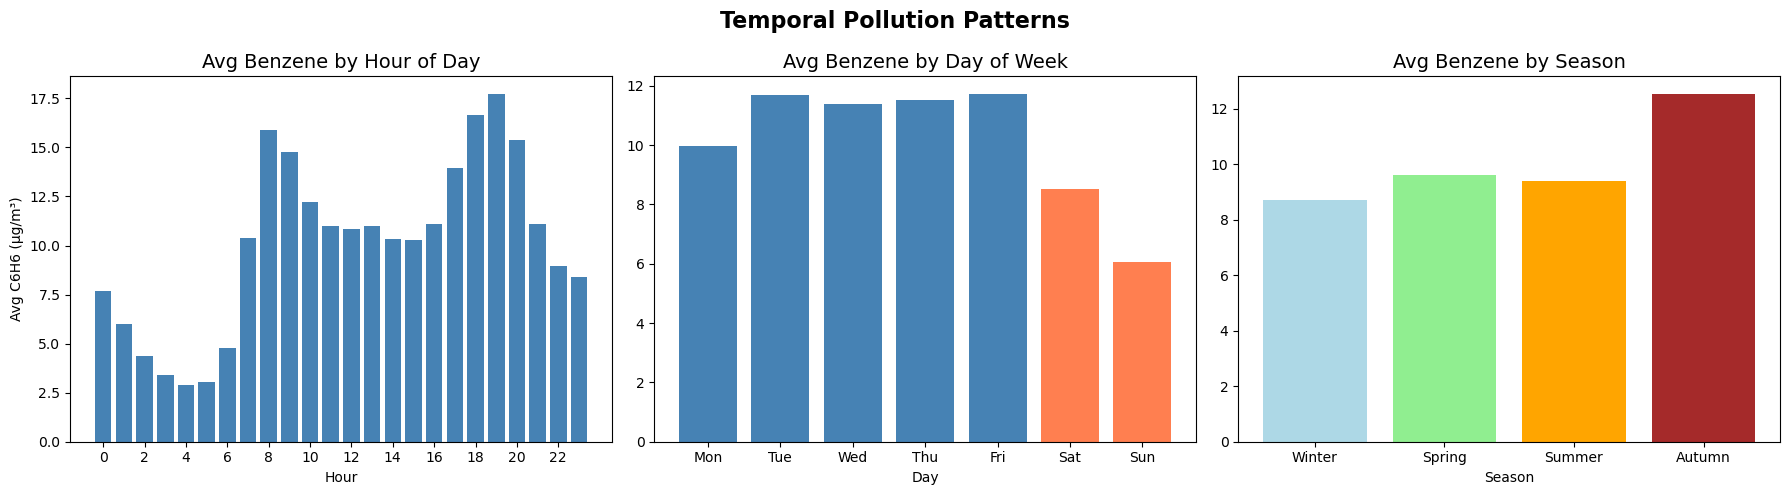

In [16]:
# Visualize Temporal features 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
hourly = df.groupby('Hour')['C6H6(GT)'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].set_title('Avg Benzene by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Avg C6H6 (µg/m³)')
axes[0].set_xticks(range(0, 24, 2))

# By day of week
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df.groupby('DayOfWeek')['C6H6(GT)'].mean()
axes[1].bar(days, daily.values, color=['steelblue']*5 + ['coral']*2)
axes[1].set_title('Avg Benzene by Day of Week')
axes[1].set_xlabel('Day')

# By season
seasons = ['Winter','Spring','Summer','Autumn']
seasonal = df.groupby('Season')['C6H6(GT)'].mean()
axes[2].bar(seasons, seasonal.values, color=['lightblue','lightgreen','orange','brown'])
axes[2].set_title('Avg Benzene by Season')
axes[2].set_xlabel('Season')

plt.suptitle('Temporal Pollution Patterns', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

# Splitting The data

In [17]:
TARGET   = 'C6H6(GT)'
FEATURES = [c for c in df.columns if c != TARGET]

X = df[FEATURES]
y = df[TARGET]

split_idx = int(len(df) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {X_train.shape}  |  {X_train.index.min().date()} → {X_train.index.max().date()}')
print(f'Test:  {X_test.shape}   |  {X_test.index.min().date()} → {X_test.index.max().date()}')

Train: (7192, 16)  |  2004-03-10 → 2005-01-16
Test:  (1799, 16)   |  2005-01-16 → 2005-04-04


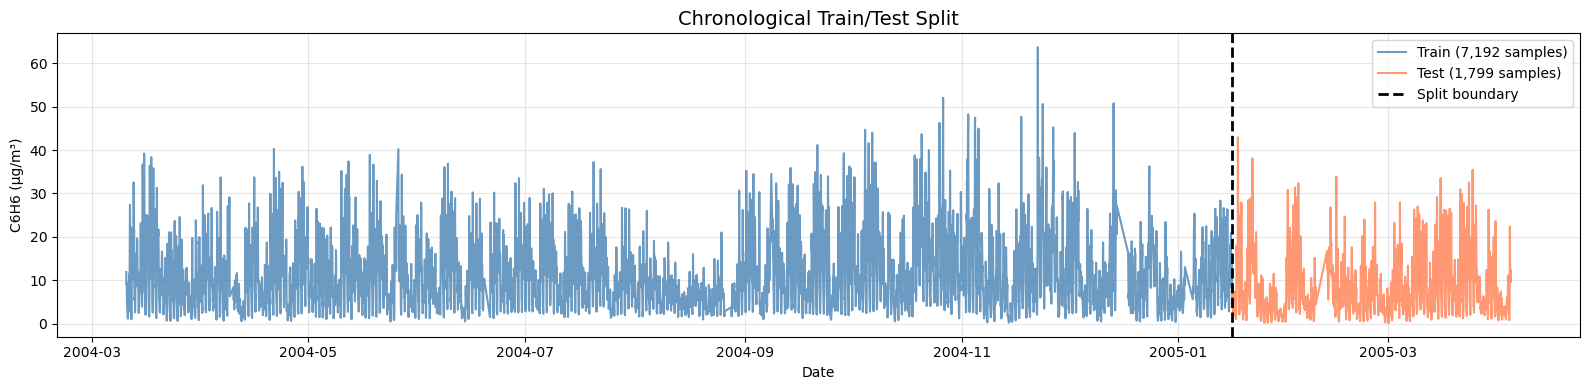

In [18]:
# Visualize the split
plt.figure(figsize=(16, 4))
plt.plot(y_train.index, y_train.values, color='steelblue',
         label=f'Train ({len(y_train):,} samples)', alpha=0.8)
plt.plot(y_test.index, y_test.values, color='coral',
         label=f'Test ({len(y_test):,} samples)', alpha=0.8)
plt.axvline(x=y_test.index[0], color='black', linestyle='--',
            linewidth=2, label='Split boundary')
plt.title('Chronological Train/Test Split')
plt.xlabel('Date')
plt.ylabel('C6H6 (µg/m³)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig5_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Scale features 
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [20]:
#  funcution for evaluation 
def evaluate_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:<32} | MAE: {mae:6.3f} | RMSE: {rmse:6.3f} | R²: {r2:.4f}')
    return {'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R2': round(r2,4)}

results     = []
predictions = {}

# Fit the models
#Model Training — Initial Run (All Features)
We first train all four models using the full feature set (including reference analyzer columns) as a benchmark. This initial run will later reveal a critical data integrity issue.

Models Evaluated:
Linear Regression — baseline, assumes linear relationships
SVR (RBF kernel) — robust to noise, handles non-linear patterns
Random Forest — ensemble of 100 trees, resistant to outliers
Gradient Boosting — sequential 200-tree ensemble, learns from residuals

In [21]:
#  Linear Regression (Baseline)
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
results.append(evaluate_model('Linear Regression (Baseline)', y_test, lr_preds))
predictions['Linear Regression'] = lr_preds

  Linear Regression (Baseline)     | MAE:  1.792 | RMSE:  2.055 | R²: 0.9006


In [22]:
#  SVR  
#we use the  scaled data 
svr = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr.fit(X_train_sc, y_train)
svr_preds = svr.predict(X_test_sc)
results.append(evaluate_model('SVR (RBF kernel)', y_test, svr_preds))
predictions['SVR'] = svr_preds

  SVR (RBF kernel)                 | MAE:  0.674 | RMSE:  1.057 | R²: 0.9737


In [23]:
# Random Forest 
rf = RandomForestRegressor(n_estimators=100, min_samples_split=5,random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, rf_preds))
predictions['Random Forest'] = rf_preds


  Random Forest                    | MAE:  0.005 | RMSE:  0.043 | R²: 1.0000


In [24]:
# Gradient Boosting 
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, gb_preds))
predictions['Gradient Boosting'] = gb_preds

  Gradient Boosting                | MAE:  0.007 | RMSE:  0.026 | R²: 1.0000


In [25]:
# Summary table
results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(' FINAL RESULTS :')
print('=' * 65)
print(results_df.to_string(index=False))

 FINAL RESULTS :
                       Model    MAE   RMSE     R2
               Random Forest 0.0048 0.0433 1.0000
           Gradient Boosting 0.0075 0.0258 1.0000
            SVR (RBF kernel) 0.6741 1.0571 0.9737
Linear Regression (Baseline) 1.7916 2.0545 0.9006


# Visualize the metrics

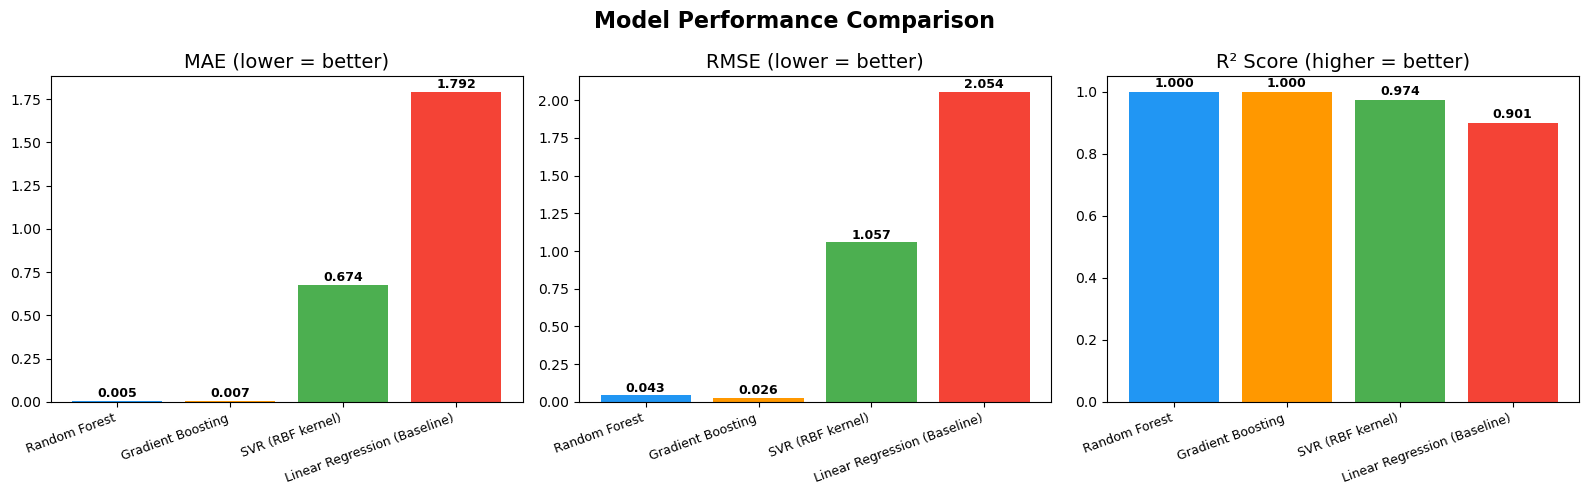

In [26]:
# Bar chart comparison 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#2196F3','#FF9800','#4CAF50','#F44336']
models = results_df['Model'].tolist()
x = np.arange(len(models))

for ax, metric, title in zip(axes,
                              ['MAE','RMSE','R2'],
                              ['MAE (lower = better)',
                               'RMSE (lower = better)',
                               'R² Score (higher = better)']):
    ax.bar(x, results_df[metric], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.set_title(title)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

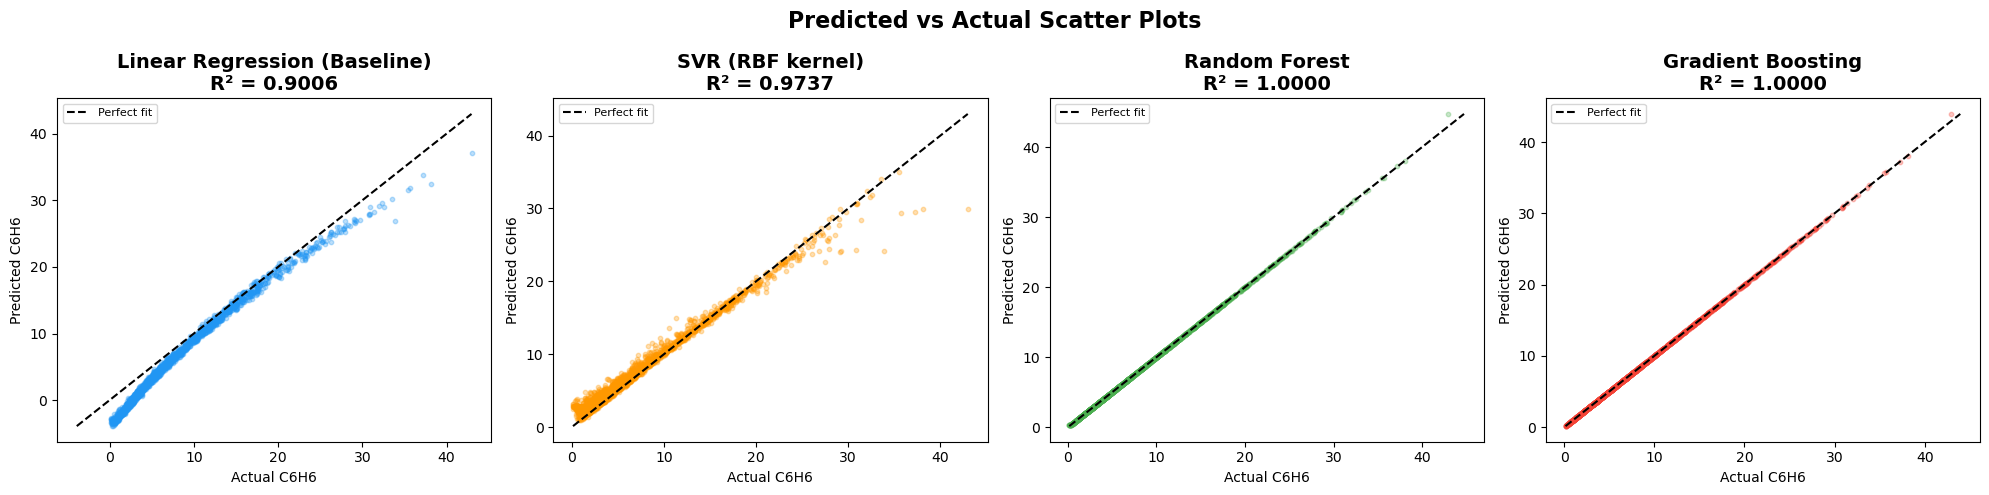

In [27]:
# Scatter plots: Predicted vs Actual
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
model_list = [
    ('Linear Regression (Baseline)', lr_preds,  '#2196F3'),
    ('SVR (RBF kernel)',             svr_preds, '#FF9800'),
    ('Random Forest',                rf_preds,  '#4CAF50'),
    ('Gradient Boosting',            gb_preds,  '#F44336'),
]
for ax, (name, preds, color) in zip(axes, model_list):
    ax.scatter(y_test, preds, alpha=0.3, color=color, s=10)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.4f}', fontweight='bold')
    ax.set_xlabel('Actual C6H6')
    ax.set_ylabel('Predicted C6H6')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual Scatter Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Issue Found: Data Exposure
After running our first set of experiments we discovered that Random Forest and Gradient Boosting both obtained R2 = 1.0000, a perfect score that is unrealistic for any machine learning problem found in the real world.

### What Went Wrong?
We discovered that certain columns had an excessively strong correlation with benzene when we examined the correlation between all features and our target variable
- CO(GT) — measured by the expensive reference analyzer
- NOx(GT) — measured by the expensive reference analyzer
- NO2(GT) — measured by the expensive reference analyzer
- PT08.S2(NMHC) — a sensor that directly measures the same pollutant 
  family as benzene, with a correlation of approximately 0.98
### Why Is This an Issue?
According to our project proposal, the objective is to use inexpensive sensors, which range in price from $100 to $500, to predict benzene. Nevertheless, a closer look at our feature set revealed that some of the columns we included—CO(GT), NOx(GT), and NO2(GT) in particular—are measurements from the pricey reference analyzer itself.
This meant that our results were not entirely in line with the real-world scenario we outlined in the proposal, even though it had no impact on the validity of our preprocessing or modeling procedures. Due to the costly equipment needed to measure them, these reference values would not be available to a low-cost monitoring station placed in the field.
### The Solution
We removed all ground truth reference columns and the highly correlated 
sensor signal PT08.S2(NMHC), keeping only the features that a real 
low-cost monitoring station would actually have available.

In [28]:
SENSOR_FEATURES = [
    'PT08.S1(CO)',    # CO sensor signal
    # 'PT08.S2(NMHC)' ← REMOVED — too correlated with benzene
    'PT08.S3(NOx)',   # NOx sensor signal
    'PT08.S4(NO2)',   # NO2 sensor signal
    'PT08.S5(O3)',    # O3 sensor signal
    'T',              # Temperature
    'RH',             # Relative Humidity
    'AH',             # Absolute Humidity
    'Hour',           # Time of day
    'DayOfWeek',      # Day of week
    'Month',          # Month
    'IsWeekend',      # Weekend flag
    'Season'          # Season
]

print(f'Using {len(SENSOR_FEATURES)} features')



Using 12 features


In [29]:
TARGET = 'C6H6(GT)'

X_f2 = df[SENSOR_FEATURES]
y_f2 = df[TARGET]

split_idx = int(len(df) * 0.80)

X_train_f2, X_test_f2 = X_f2.iloc[:split_idx], X_f2.iloc[split_idx:]
y_train_f2, y_test_f2 = y_f2.iloc[:split_idx], y_f2.iloc[split_idx:]

scaler_f2      = StandardScaler()
X_train_f2_sc  = scaler_f2.fit_transform(X_train_f2)
X_test_f2_sc   = scaler_f2.transform(X_test_f2)

print(f'Train: {X_train_f2.shape} | {X_train_f2.index.min().date()} → {X_train_f2.index.max().date()}')
print(f'Test : {X_test_f2.shape}  | {X_test_f2.index.min().date()} → {X_test_f2.index.max().date()}')

Train: (7192, 12) | 2004-03-10 → 2005-01-16
Test : (1799, 12)  | 2005-01-16 → 2005-04-04


In [30]:
results_fix2   = []
predictions_fix2 = {}

In [31]:
# Model 1 — Linear Regression
print('Training Linear Regression - Sensor Only...')
lr_f2 = LinearRegression()
lr_f2.fit(X_train_f2_sc, y_train_f2)
lr_preds_f2 = lr_f2.predict(X_test_f2_sc)
results_fix2.append(evaluate_model('Linear Regression - Sensor Only', y_test_f2, lr_preds_f2))
predictions_fix2['Linear Regression - Sensor Only'] = lr_preds_f2

Training Linear Regression - Sensor Only...
  Linear Regression - Sensor Only  | MAE:  3.338 | RMSE:  3.939 | R²: 0.6345


In [32]:
# Model 2 — SVR
svr_f2 = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr_f2.fit(X_train_f2_sc, y_train_f2)
svr_preds_f2 = svr_f2.predict(X_test_f2_sc)
results_fix2.append(evaluate_model('SVR - Sensor Only', y_test_f2, svr_preds_f2))
predictions_fix2['SVR - Sensor Only'] = svr_preds_f2

  SVR - Sensor Only                | MAE:  1.315 | RMSE:  1.810 | R²: 0.9228


In [33]:
# Model 3 — Random Forest
rf_f2 = RandomForestRegressor(n_estimators=100, min_samples_split=5,
                               random_state=42, n_jobs=-1)
rf_f2.fit(X_train_f2, y_train_f2)
rf_preds_f2 = rf_f2.predict(X_test_f2)
results_fix2.append(evaluate_model('Random Forest - Sensor Only', y_test_f2, rf_preds_f2))
predictions_fix2['Random Forest - Sensor Only'] = rf_preds_f2


  Random Forest - Sensor Only      | MAE:  2.079 | RMSE:  2.607 | R²: 0.8398


In [34]:
# Model 4 — Gradient Boosting
gb_f2 = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                   max_depth=5, subsample=0.8, random_state=42)
gb_f2.fit(X_train_f2, y_train_f2)
gb_preds_f2 = gb_f2.predict(X_test_f2)
results_fix2.append(evaluate_model('Gradient Boosting - Sensor Only', y_test_f2, gb_preds_f2))
predictions_fix2['Gradient Boosting - Sensor Only'] = gb_preds_f2

  Gradient Boosting - Sensor Only  | MAE:  1.394 | RMSE:  1.983 | R²: 0.9074


In [35]:
results_df_f2 = pd.DataFrame(results_fix2).sort_values('R2', ascending=False).reset_index(drop=True)

print('=' * 65)
print('    SENSOR ONLY FEATURES')
print('=' * 65)
print(results_df_f2.to_string(index=False))
print('=' * 65)
print(f'\n Best Model: {results_df_f2.iloc[0]["Model"]}')

    SENSOR ONLY FEATURES
                          Model    MAE   RMSE     R2
              SVR - Sensor Only 1.3145 1.8103 0.9228
Gradient Boosting - Sensor Only 1.3944 1.9830 0.9074
    Random Forest - Sensor Only 2.0786 2.6074 0.8398
Linear Regression - Sensor Only 3.3377 3.9387 0.6345

 Best Model: SVR - Sensor Only


In [39]:
# Add Scenario label to BOTH dataframes
results_df['Scenario']    = 'Before (with leakage)'
results_df_f2['Scenario'] = 'Sensor Only'

combined = pd.concat([
    results_df[['Scenario','Model','MAE','RMSE','R2']],
    results_df_f2[['Scenario','Model','MAE','RMSE','R2']]
], ignore_index=True)

print('=' * 75)
print('            BEFORE vs AFTER — FULL COMPARISON')
print('=' * 75)
print(combined.to_string(index=False))
print('=' * 75)

            BEFORE vs AFTER — FULL COMPARISON
             Scenario                           Model    MAE   RMSE     R2
Before (with leakage)                   Random Forest 0.0048 0.0433 1.0000
Before (with leakage)               Gradient Boosting 0.0075 0.0258 1.0000
Before (with leakage)                SVR (RBF kernel) 0.6741 1.0571 0.9737
Before (with leakage)    Linear Regression (Baseline) 1.7916 2.0545 0.9006
          Sensor Only               SVR - Sensor Only 1.3145 1.8103 0.9228
          Sensor Only Gradient Boosting - Sensor Only 1.3944 1.9830 0.9074
          Sensor Only     Random Forest - Sensor Only 2.0786 2.6074 0.8398
          Sensor Only Linear Regression - Sensor Only 3.3377 3.9387 0.6345


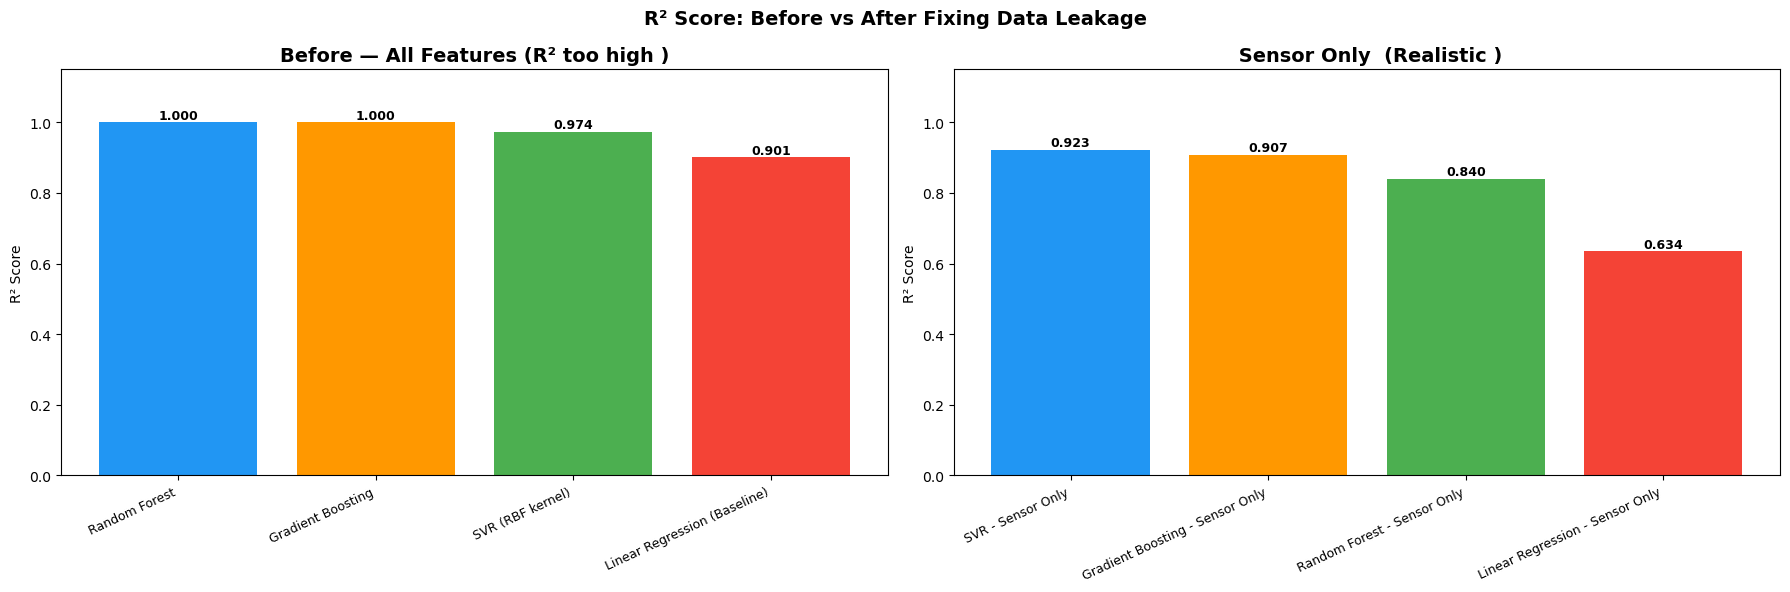

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#F44336']
x = np.arange(4)

for ax, (title, df_res) in zip(axes, [
    ('Before — All Features (R² too high )', results_df),
    (' Sensor Only  (Realistic )',    results_df_f2)
]):
    ax.bar(x, df_res['R2'], color=colors)
    ax.set_xticks(x)
    ax.set_xticklabels(df_res['Model'], rotation=25, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('R² Score')
    ax.set_ylim(0, 1.15)
    for i, v in enumerate(df_res['R2']):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center',
                fontsize=9, fontweight='bold')

plt.suptitle('R² Score: Before vs After Fixing Data Leakage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
import pickle

model_package = {
    'model'    : svr_f2,
    'scaler'   : scaler_f2,
    'features' : SENSOR_FEATURES
}

with open('benzene_model.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print('Model saved as benzene_model.pkl')
print(f'Features: {SENSOR_FEATURES}')

Model saved as benzene_model.pkl
Features: ['PT08.S1(CO)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Season']


# Github link 

https://github.com/arwa15320/benzene-predictor

# Similar work Github links 
https://github.com/HarshiniR4/UCI-Air-Quality-Dataset-EDA


https://github.com/asharvi1/UCI-Air-Quality-Data

https://github.com/SonalSavaliya/Prediction-of-Nitrogen-Oxides-level-in-Air-Quality